In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join
import os
import seaborn as sns

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir, google_folder_id, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

Added to sys: d:\GMM 4\Reading seminar\Projet-recheche-INSA-anomaly-detection-librairy\src


# Goal

- Compare the performance of iForest, PCA/DPCA and iForest in PCA space

# PCA Space construction

In [2]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

In [3]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

In [4]:
len(list_session)

40

## Function to create whole dataset

In [5]:
import random

def create_session_anomaly(data_dict, session_anomaly):
    """
    Create a list of anomalous session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of anomalous session path
    session_anomaly_list = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] in session_anomaly:
            session_anomaly_list.append(s)
    
    return session_anomaly_list

def create_session_clean(data_dict, session_anomaly):
    """
    Create a list of clean session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of clean session path
    session_clean = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] not in session_anomaly:
            session_clean.append(s)
    
    return session_clean


def split_session(session_clean, p=2/3, seed = None):
    """
    split the list of clean session path into train and test
    """
    if seed is not None:
        random.seed(seed)
    sessions = session_clean.copy()
    random.shuffle(sessions)
    n_train = int(len(sessions) * p)
    session_train = sessions[:n_train]
    session_test = sessions[n_train:]
    return session_train, session_test

def merge_dataset(data_dict, session):
    """ 
    Preprocess the session in the list session and concatenate to a single dataset
    """
    temp_list = []
    for s in session:
        df = data_dict[s].copy()
        df = preprocessing.clean_dataframe(df)
        df['session_id'] = os.path.splitext(os.path.basename(s))[0]
        temp_list.append(df)

    df_train = pd.concat(temp_list, ignore_index=True)
    return df_train

def create_dataset(data_dict, session_anomaly, split=False, p=2/3, seed=423):
    """
    Create the whole preprocessed dataset and remove the anomalous sessions. 

    data_dict (dict): The dictionnary containing all data
    session_anomaly (list): List of name of anomalous sessions
    split (bool): If True, split the dataset to train and test dataset
    p (int, 0<p<1): Ratio train/test
    seed (int): random seed for the split

    Return : 
    if split is False, return whole dataset and the session path list
    if split is True, return train dataset, test dataset and their session path list

    """
    #Create session clean list
    session_clean = create_session_clean(data_dict, session_anomaly)

    # if split is False, we will prerpocess all data
    session_train = session_clean 
    
    # Create train data session path list and test data session path list
    if split :
        session_train, session_test = split_session(session_clean, p, seed)
    
    # Create train dataset
    df_train = merge_dataset(data_dict, session_train)

    # Create test dataset
    if split:
        df_test = merge_dataset(data_dict, session_test)
        return df_train, df_test, session_train, session_test
        
    return df_train, session_train


In [6]:
# example of creating train dataset and test dataset
session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']
df_all, df_all_test, list_train, list_test= create_dataset(data_dict, session_anomaly,split=True, seed=423)
cols = [c for c in df_all.columns if c not in ['session_id', 'time_real', 'datetime', ]]

In [7]:
list_test_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in list_test
]
np.array(list_test_names)

array(['T24S12-04_E-AL3358', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3479',
       'T24S12-04_E-AL3499', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3538',
       'T24S12-04_E-AL3438', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3014',
       'T24S12-04_E-AL3221'], dtype='<U18')

In [8]:
list_train_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in list_train
]
np.array(list_train_names)

array(['T24S12-04_E-AL3458', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL3577',
       'T24S12-04_E-AL3070', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2870',
       'T24S12-04_E-AL3417', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671',
       'T24S12-04_E-AL2889', 'T24S12-04_E-AL3143', 'T24S12-04_E-AL2987',
       'T24S12-04_E-AL3339', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3240',
       'T24S12-04_E-AL3319', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3690',
       'T24S12-04_E-AL3033', 'T24S12-04_E-AL3280'], dtype='<U18')

## iForest global

In [9]:
from anomaly_detection.deep_learning.isolation_forest import AnomalyDetectorIF
features = [c for c in df_all.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_glob = AnomalyDetectorIF(contamination=0.01)
clf_glob.fit(df_all, features)


## Train data and test data

In [10]:
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

In [11]:
# Create a list of clean session path

session_clean = create_session_clean(data_dict, session_anomaly)
session_clean_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_clean
]
np.array(session_clean_names)

array(['T24S12-04_E-AL2870', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL2909',
       'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014',
       'T24S12-04_E-AL3033', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3070',
       'T24S12-04_E-AL3143', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240',
       'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3319',
       'T24S12-04_E-AL3339', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL3377',
       'T24S12-04_E-AL3397', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438',
       'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499',
       'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577',
       'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690'],
      dtype='<U18')

In [12]:
import random

seed = 423

session_train, session_test= split_session(session_clean, seed = seed)
print(len(session_train), len(session_test))

20 10


In [13]:
session_test_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_test
]
np.array(session_test_names)

array(['T24S12-04_E-AL3358', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3479',
       'T24S12-04_E-AL3499', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3538',
       'T24S12-04_E-AL3438', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3014',
       'T24S12-04_E-AL3221'], dtype='<U18')

In [14]:
session_train_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_train
]
np.array(session_train_names)

array(['T24S12-04_E-AL3458', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL3577',
       'T24S12-04_E-AL3070', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2870',
       'T24S12-04_E-AL3417', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671',
       'T24S12-04_E-AL2889', 'T24S12-04_E-AL3143', 'T24S12-04_E-AL2987',
       'T24S12-04_E-AL3339', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3240',
       'T24S12-04_E-AL3319', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3690',
       'T24S12-04_E-AL3033', 'T24S12-04_E-AL3280'], dtype='<U18')

## Dataset

### PCA

In [15]:
from sklearn.neighbors import LocalOutlierFactor
def replace_outliers_moving_average(df, cols, outlier_mask, window=20):
    """
    Replace LOF outliers using moving average interpolation.

    Parameters
    ----------
    df : pandas DataFrame
    cols : columns to clean
    outlier_mask : boolean array (True = outlier)
    window : moving average window size

    Returns
    -------
    df_clean : cleaned dataframe
    """

    df_clean = df.copy()

    for col in cols:

        # compute rolling mean
        rolling_mean = df_clean[col].rolling(window=window, center=True, min_periods=1).mean()

        # replace outliers
        df_clean.loc[outlier_mask, col] = rolling_mean[outlier_mask]

    return df_clean

In [16]:
# Train PCA of standardized data

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from anomaly_detection.dimension_reduction.pca import dynamic_augmentation, inverse_dynamic_augmentation, lag_augmented
from scipy.stats import chi2

scaler = StandardScaler()
pca = PCA()
ncp = 3
lag = 8

In [17]:
temp_list = []

for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        if s == session_train[7]:
            df = df.iloc[:9200,:]
        temp_list.append(df)

df_train = pd.concat(temp_list, ignore_index=True)
scaler = StandardScaler()
pca = PCA(n_components=ncp)
respca = pca.fit_transform(scaler.fit_transform(df_train[cols]))
df_train_inv = pca.inverse_transform(respca)
SPEpca = np.sum((scaler.transform(df_train[cols]) - df_train_inv)**2,axis=1)


a = np.mean(SPEpca)
b = np.var(SPEpca)
alpha = 0.01
nu = 2 * a**2 / b
seuil = (b / (2*a)) * chi2.ppf(1 - alpha, nu)

### iForest PCA

In [18]:
from anomaly_detection.deep_learning.isolation_forest import AnomalyDetectorIF
df_if = pd.DataFrame(respca)
features = [c for c in df_if.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_if = AnomalyDetectorIF(contamination=0.01)
clf_if.fit(df_if, features)

### DPCA

In [19]:
temp_list = []
session_index = []
i = 0

for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        if i == 7:
            df = df.iloc[:9200,:]
        df = scaler.transform(df[cols])
        df = dynamic_augmentation(df, s=lag)
        temp_list.append(pd.DataFrame(df))
        session_index.append(np.ones(df.shape[0])*i)
        i = i+1

df_train_dy = pd.concat(temp_list, ignore_index=True)
dpca = PCA(n_components=ncp)
resdpca = dpca.fit_transform(df_train_dy)
df_train_dy_inv = dpca.inverse_transform(resdpca)
resid_dpca = df_train_dy - df_train_dy_inv
error_dy = resid_dpca**2
SPEd = np.sum(error_dy, axis = 1)

a = np.mean(SPEd)
b = np.var(SPEd)
alpha = 0.01
nu = 2 * a**2 / b
seuilD = (b / (2*a)) * chi2.ppf(1 - alpha, nu)
seuilD

np.float64(84.60644068933206)

### iForest DPCA

In [20]:
df_if_dy = pd.DataFrame(resdpca)
features = [c for c in df_if_dy.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_if_dy = AnomalyDetectorIF(contamination=0.01)
clf_if_dy.fit(df_if_dy, features)

# Analysis on test data

## Functions

In [46]:
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_anomalies(df, anomaly_mask, cols, method="pca"):
    """
    Visualize anomalies on the original signal

    Parameters
    ----------
    df : pandas DataFrame
        The original dataframe containing the signals and time
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    cols : list of str
        The list of columns to visualize

    Returns
    -------
    None
    """
    # Visualize anomalies
    dff = df.copy()
    if method == "dpca":
        dff = df.iloc[lag:,:].reset_index(drop=True)
    anomaly_times = dff.loc[anomaly_mask, 'time_real']

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
    axes = axes.flatten()

    for ax, col in zip(axes, cols[:nrows * ncols]):

        # original signal plot
        visualisation.plot(dff, 'time_real', col, ax=ax)

        # overlay anomaly points
        ax.scatter(
            anomaly_times,
            dff.loc[anomaly_mask, col],
            color='red',
            s=10,
            label='SPE anomaly',
            zorder=3
        )

        ax.legend(loc="upper right", fontsize=8)

    # hide unused axes
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

def pca_anomaly_detection(df, PCA, SCALER, seuil, d=4, method="SPE", clf_IF=None):
    """
    Apply PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    PCA : PCA object
        The trained PCA model
    SCALER : StandardScaler object
        The trained scaler used for PCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    res_pca = PCA.transform(df_center)
    if method == "SPE":
        res_pca[:,d:] = 0
        df_inv = PCA.inverse_transform(res_pca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_pca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

def dpca_anomaly_detection(df, DPCA, SCALER, seuil, d=4, method="SPE", clf_IF=None):
    """
    Apply dynamic PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    DPCA : PCA object
        The trained dynamic PCA model
    SCALER : StandardScaler object
        The trained scaler used for DPCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    df_center = dynamic_augmentation(df_center, s=lag)
    res_dpca = DPCA.transform(df_center)
    if method == "SPE":
        res_dpca[:,d:] = 0
        df_inv = DPCA.inverse_transform(res_dpca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_dpca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

## PCA

### SPE

In [47]:
# Projection on PCA space of the 8th session_test

df = data_dict[session_test[8]].copy()
df = preprocessing.clean_dataframe(df)

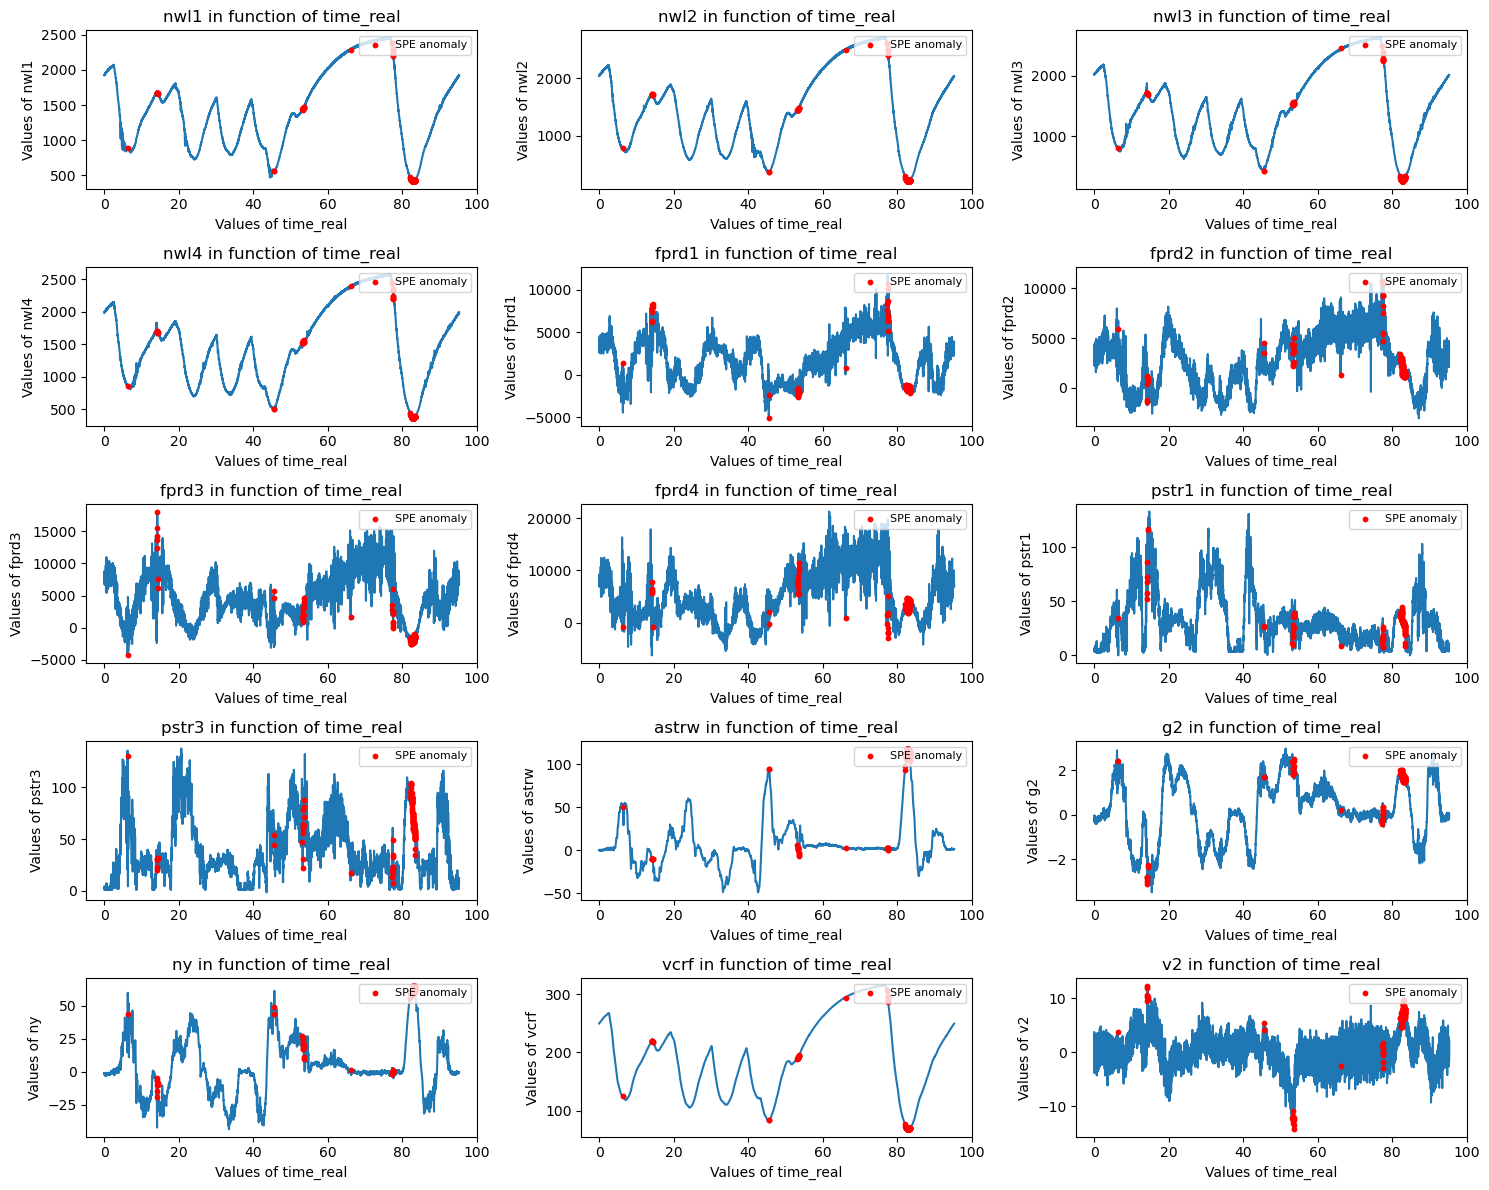

In [48]:
# Visualize anomalies

anomaly_mask = pca_anomaly_detection(df[cols], pca, scaler, seuil, d=ncp, method="SPE")
visualisation_anomalies(df, anomaly_mask, cols, method="pca")


### IF

In [49]:
# Isolation forest on PCA space
clean = clf_if.predict_anomalies(pd.DataFrame(respca))
clean

,0,1,2,anomaly_score,is_anomaly,anomaly_detected
0,2.523332,0.004076,-1.123775,0.172698,1,0
1,2.474512,-0.358248,-1.302858,0.149467,1,0
2,2.627354,-0.206757,-1.275746,0.161651,1,0
3,2.605930,-0.057352,-1.206242,0.169710,1,0
4,2.446820,-0.692054,-1.517138,0.107370,1,0
...,...,...,...,...,...,...
193168,2.677630,0.057023,-1.189491,0.173370,1,0
193169,2.577148,-0.252424,-1.385066,0.148422,1,0
193170,2.738145,0.022213,-1.236247,0.166958,1,0
193171,2.721759,-0.262012,-1.371235,0.146267,1,0


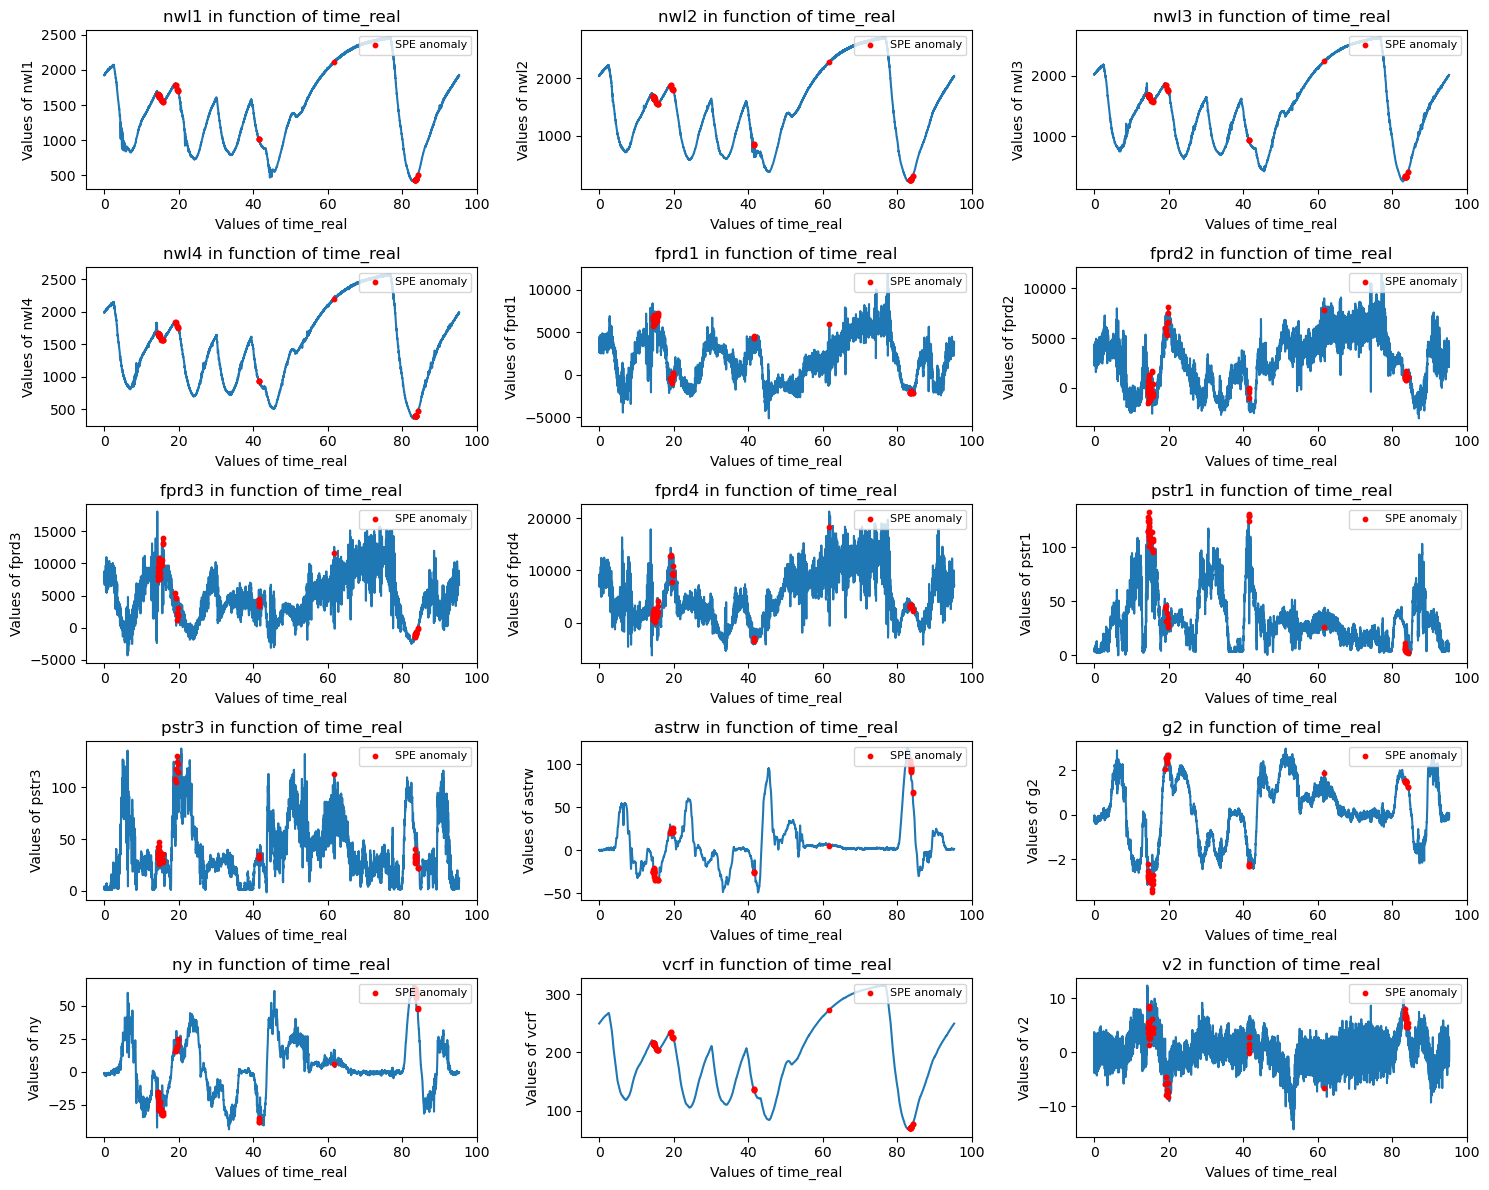

In [50]:
# Visualize anomalies
anomaly_mask = pca_anomaly_detection(df[cols], pca, scaler, seuil, d=ncp, method="IF", clf_IF=clf_if)
visualisation_anomalies(df, anomaly_mask, cols, method="pca")

## Dynamic PCA

### SPE

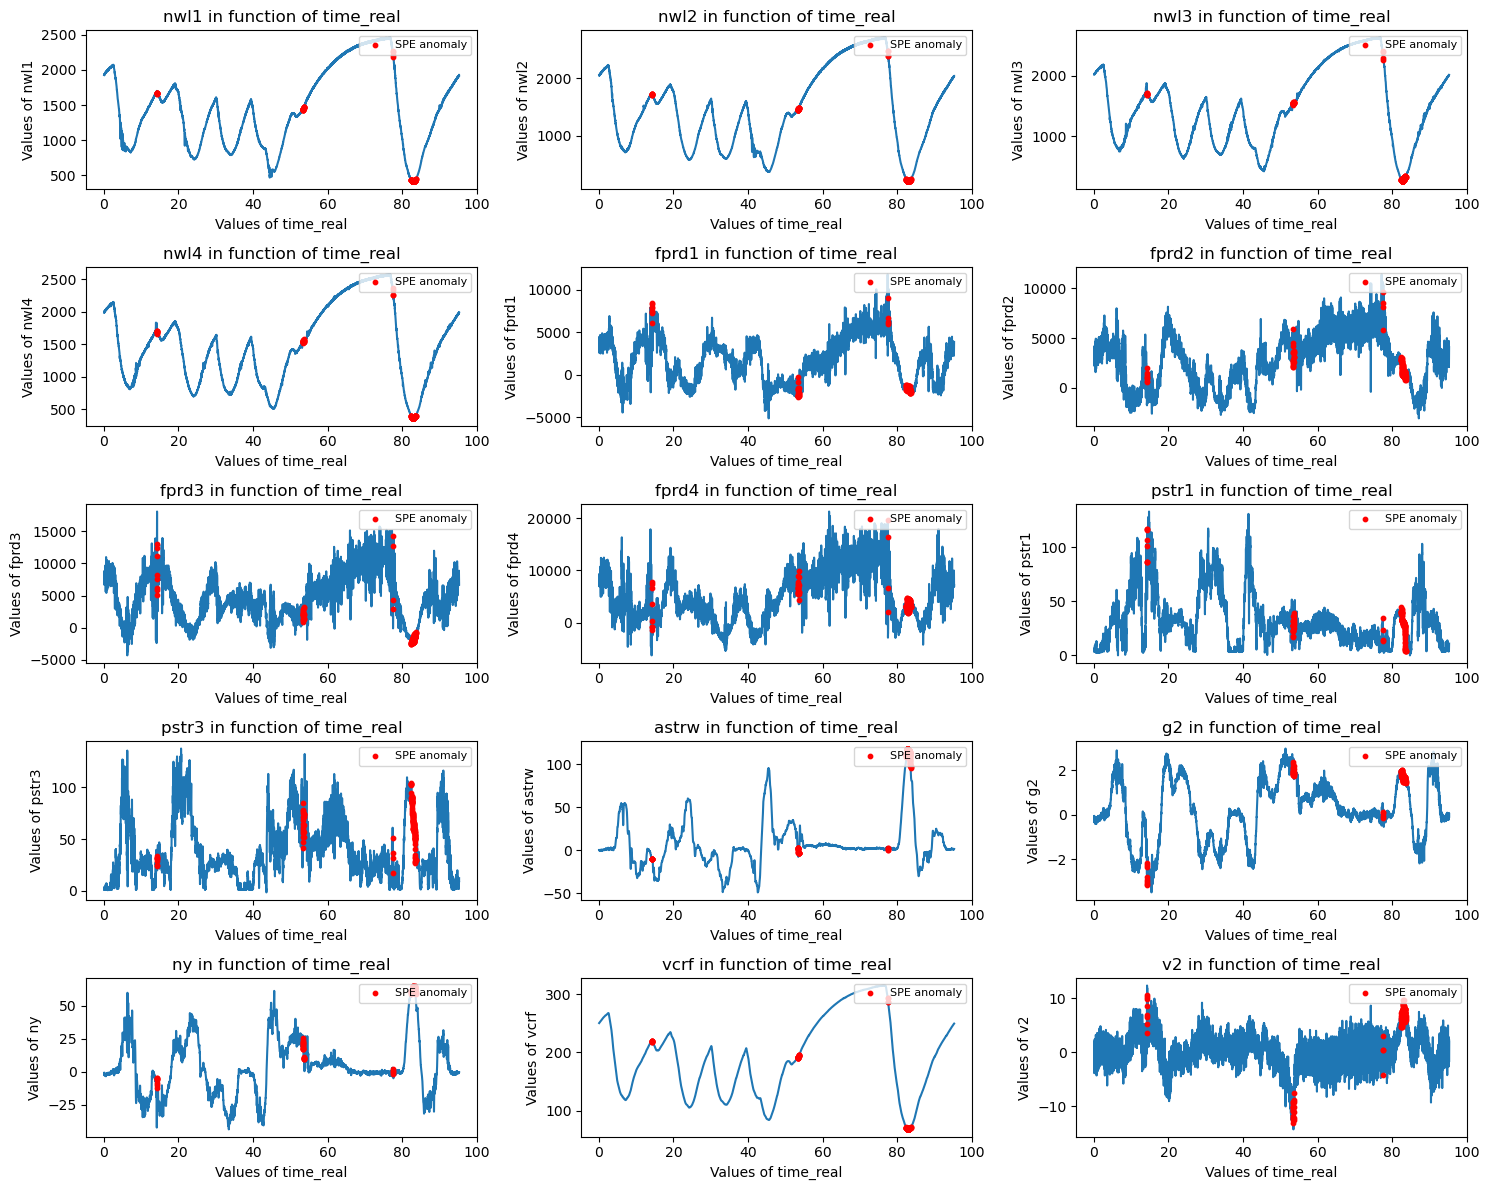

In [51]:
anomaly_mask = dpca_anomaly_detection(df[cols], dpca, scaler, seuilD, d=ncp, method="SPE")
visualisation_anomalies(df, anomaly_mask, cols, method="dpca")

### IF

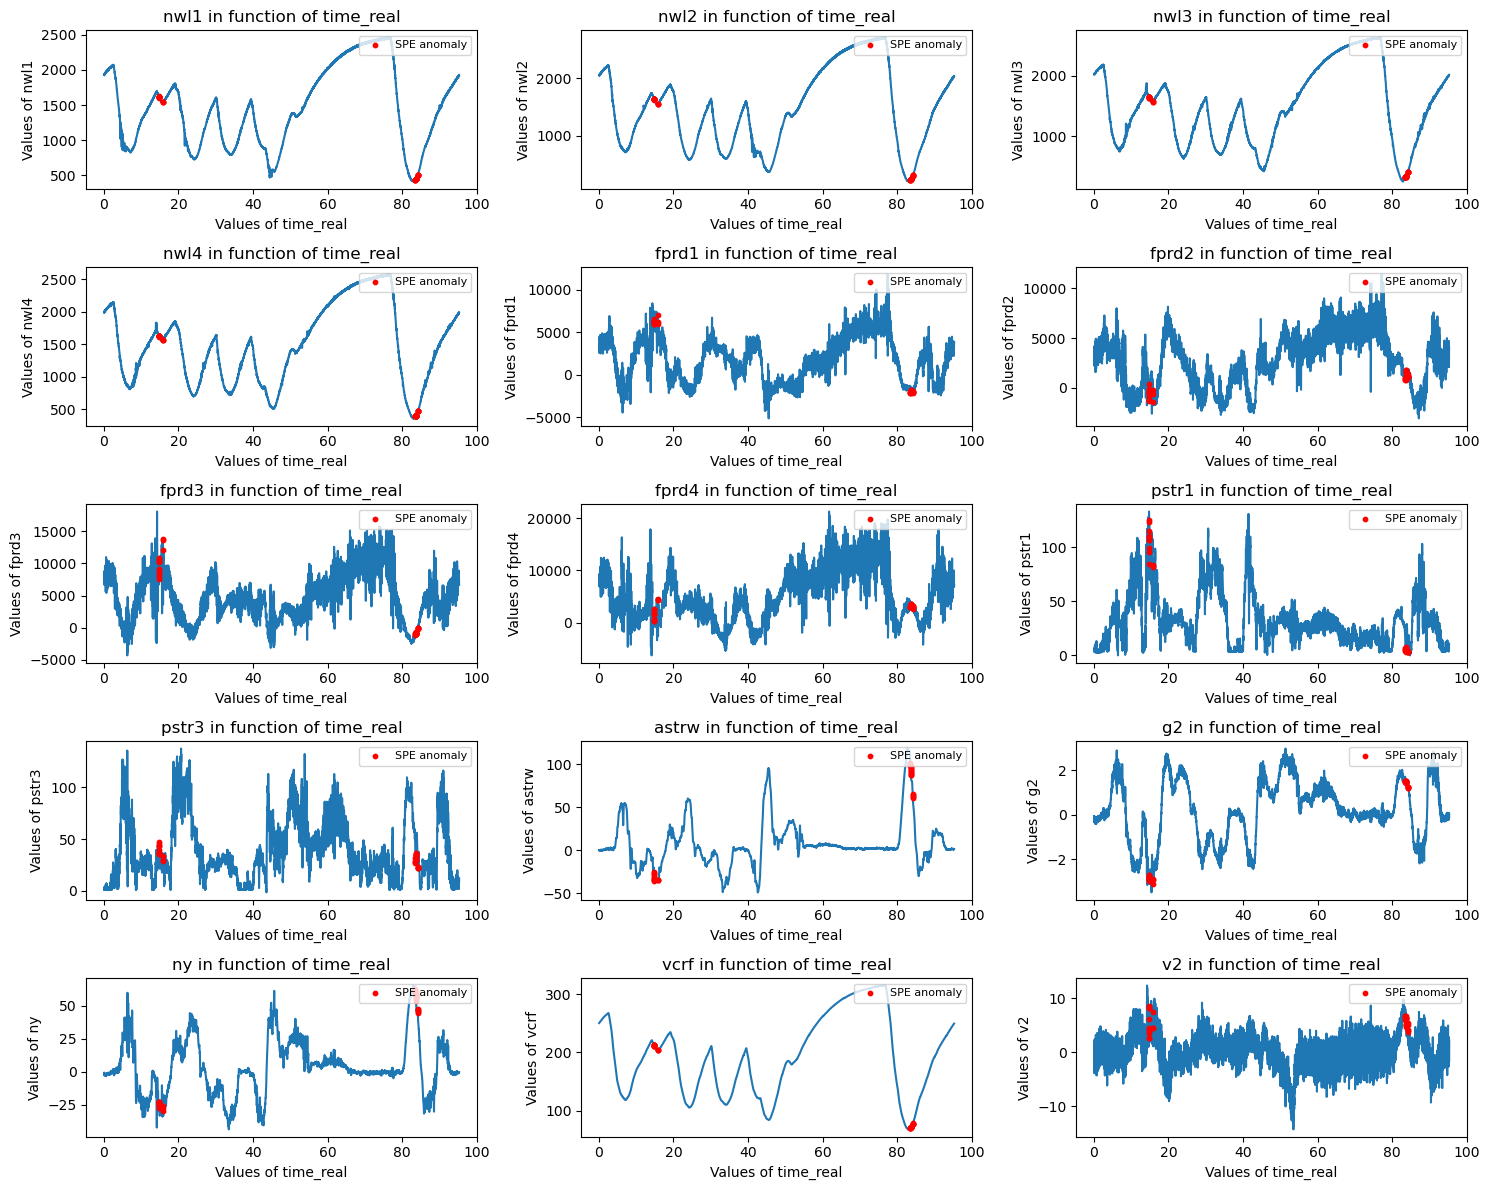

In [52]:
# Visualize anomalies
anomaly_mask_dy = dpca_anomaly_detection(df[cols], dpca, scaler, seuilD, d=ncp, method="IF", clf_IF=clf_if_dy)
visualisation_anomalies(df, anomaly_mask_dy, cols, method="dpca")

## Full test

In [53]:
results = []

for session_name in session_test:
    
    df_test = data_dict[session_name].copy()
    df_test = preprocessing.clean_dataframe(df_test)
    
    X = df_test[cols]
    n = len(X)
    
    # --- PCA ---
    mask_pca_spe = pca_anomaly_detection(X, pca, scaler, seuil, method="SPE")
    mask_pca_if  = pca_anomaly_detection(X, pca, scaler, seuil, method="IF", clf_IF=clf_if)
    
    # --- DPCA ---
    mask_dpca_spe = dpca_anomaly_detection(X, dpca, scaler, seuilD, method="SPE")
    mask_dpca_if  = dpca_anomaly_detection(X, dpca, scaler, seuilD, method="IF", clf_IF=clf_if_dy)
    
    mask_global_if = clf_glob.predict_anomalies(X)["anomaly_detected"]==1
    # --- compute percentages ---
    res = {
        "session": os.path.basename(session_name),
        "pca_spe_%": mask_pca_spe.sum() / n * 100,
        "pca_if_%":  mask_pca_if.sum() / n * 100,
        "dpca_spe_%": mask_dpca_spe.sum() / n * 100,
        "dpca_if_%":  mask_dpca_if.sum() / n * 100,
        "global_if_%": mask_global_if.sum() / n * 100,
    }
    
    results.append(res)

# convert to DataFrame
df_results = pd.DataFrame(results)

In [54]:
df_results

,session,pca_spe_%,pca_if_%,dpca_spe_%,dpca_if_%,global_if_%
0,T24S12-04_E-AL3358.csv,2.177590,1.205074,2.346723,1.046512,1.109937
1,T24S12-04_E-AL3397.csv,1.458774,1.416490,1.522199,1.416490,1.131078
2,T24S12-04_E-AL3479.csv,1.377119,1.461864,1.737288,1.483051,0.932203
3,T24S12-04_E-AL3499.csv,1.710209,0.965271,1.815130,0.881335,0.954779
4,T24S12-04_E-AL3558.csv,2.811203,1.317427,3.163900,1.120332,1.172199
5,T24S12-04_E-AL3538.csv,1.682879,0.097276,1.809339,0.038911,0.009728
6,T24S12-04_E-AL3438.csv,1.583851,1.066253,1.563147,0.973085,1.004141
7,T24S12-04_E-AL3377.csv,1.965994,2.391073,2.061637,2.359192,1.795962
8,T24S12-04_E-AL3014.csv,1.500525,0.598111,1.573977,0.346275,0.619098
9,T24S12-04_E-AL3221.csv,1.419558,1.114616,1.608833,1.093586,0.452156


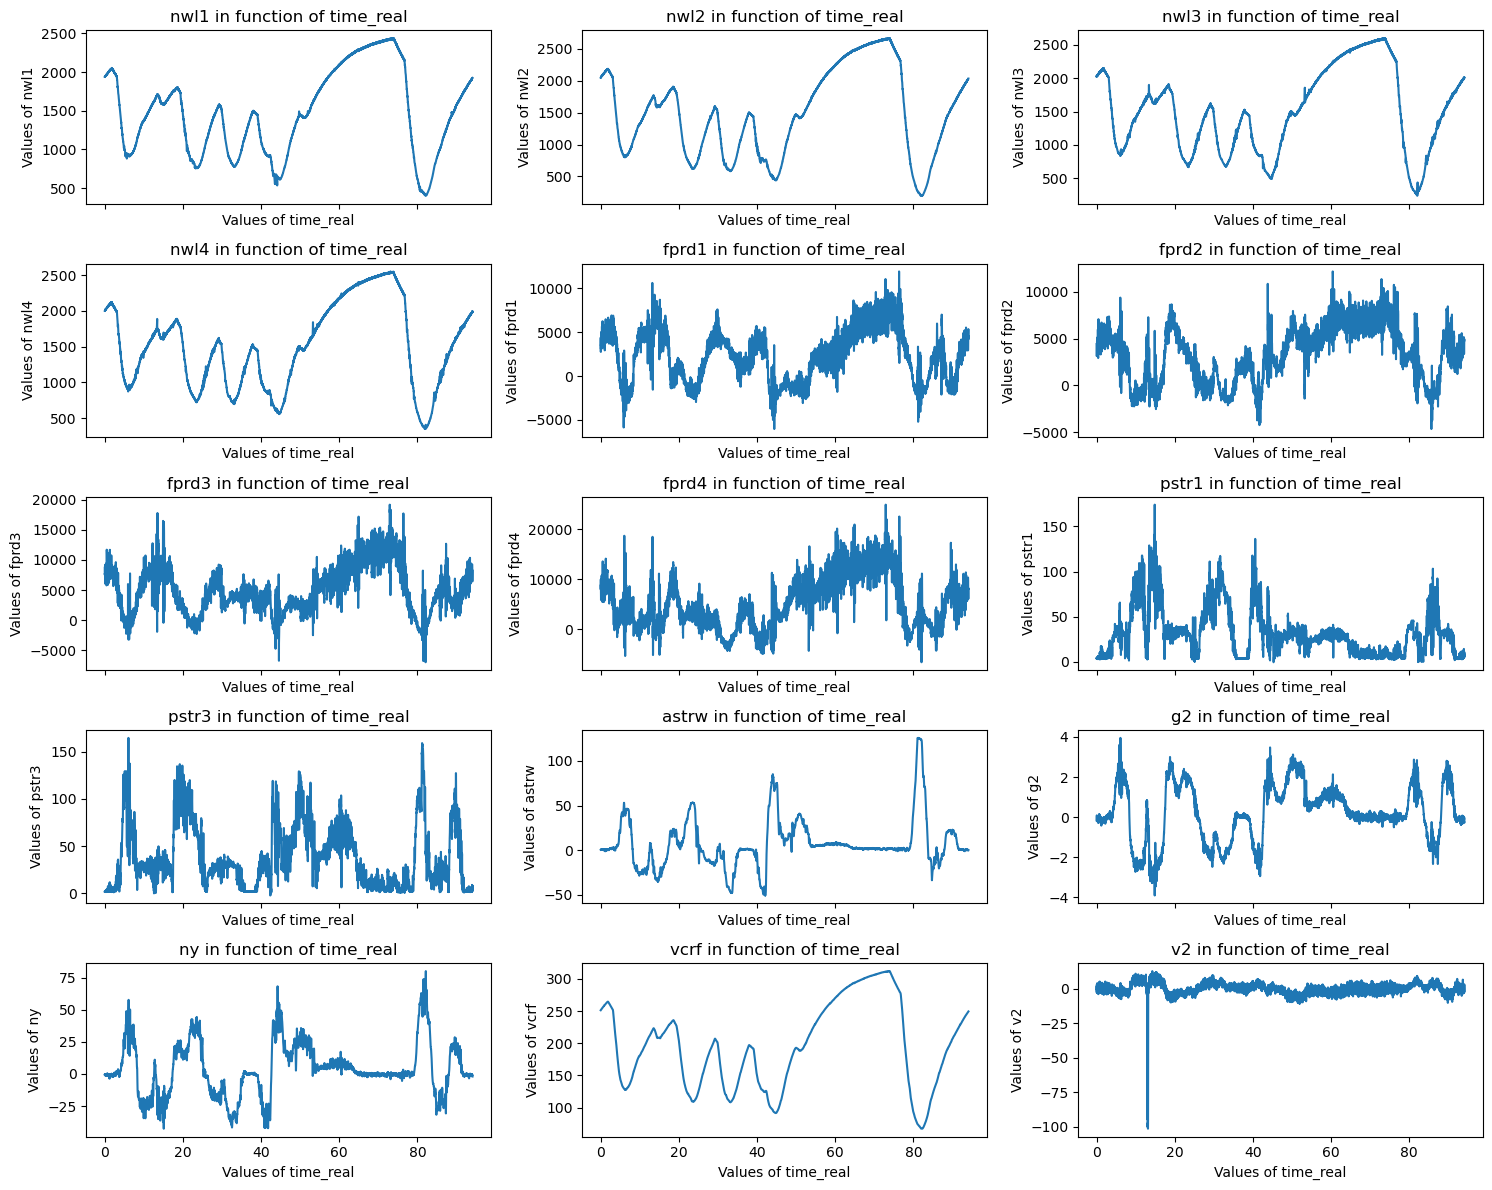

In [55]:
visualisation_plot(preprocessing.clean_dataframe(data_dict[session_test[7]]), cols)

In [56]:
# df_test = data_dict[session_test[7]].copy()
# df_test = preprocessing.clean_dataframe(df_test)
# mask_pca_anomaly = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, d=ncp, method="SPE")
# mask_pca_if = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, d=ncp, method="IF", clf_IF=clf_if)
# mask_dpca_anomaly = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, d=ncp, method="SPE")
# mask_dpca_if = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, d=ncp, method="IF", clf_IF=clf_if_dy)

In [57]:
# visualisation_anomalies(df_test, mask_dpca_if, cols, method="dpca")

## Remark
- The DPCA detects more anomalies than the PCA
- SPE detects more anomalies than iForest in both latent space and original space for clean test sessions.

# Test on anomalous sessions

In [58]:
session_anomaly_test = create_session_anomaly(data_dict, session_anomaly)
len(session_anomaly_test)

10

In [59]:
df_test = data_dict[session_anomaly_test[8]].copy()
df_test = preprocessing.clean_dataframe(df_test)
mask_pca_anomaly = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, method="SPE")
mask_pca_if = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, method="IF", clf_IF=clf_if)
mask_dpca_anomaly = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, method="SPE")
mask_dpca_if = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, method="IF", clf_IF=clf_if_dy)

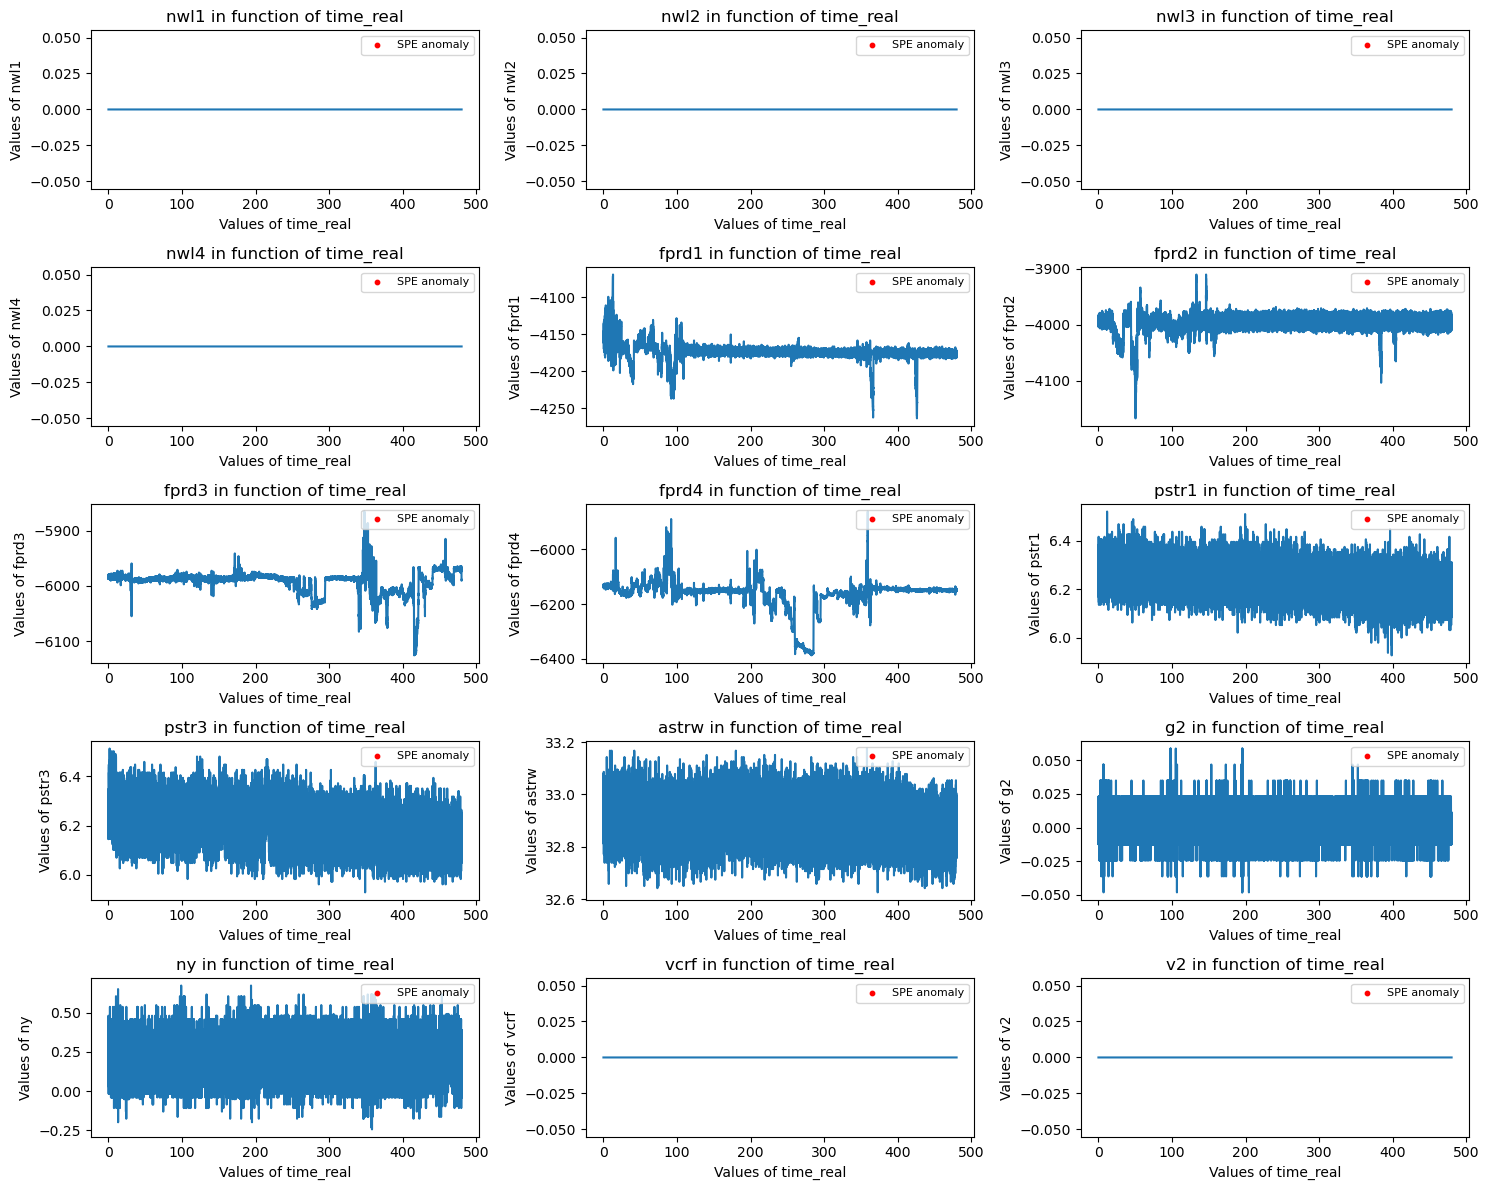

In [60]:
visualisation_anomalies(df_test, mask_pca_anomaly, cols)

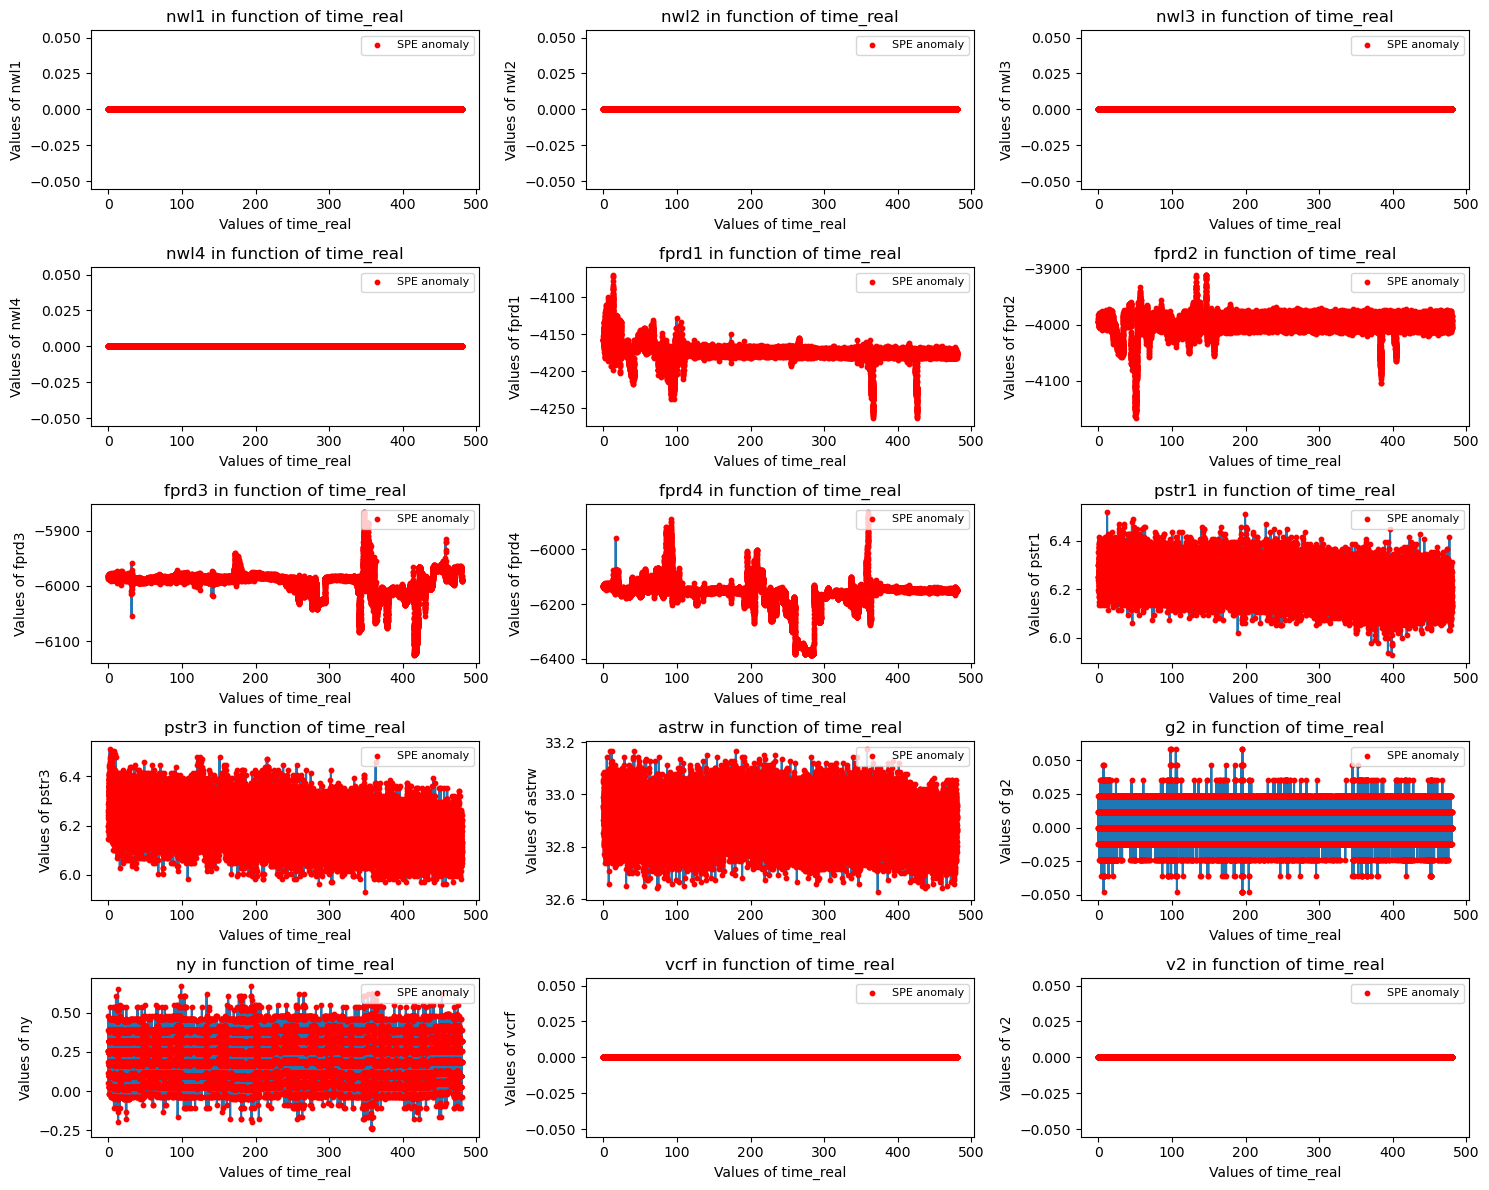

In [61]:
visualisation_anomalies(df_test, mask_pca_if, cols)

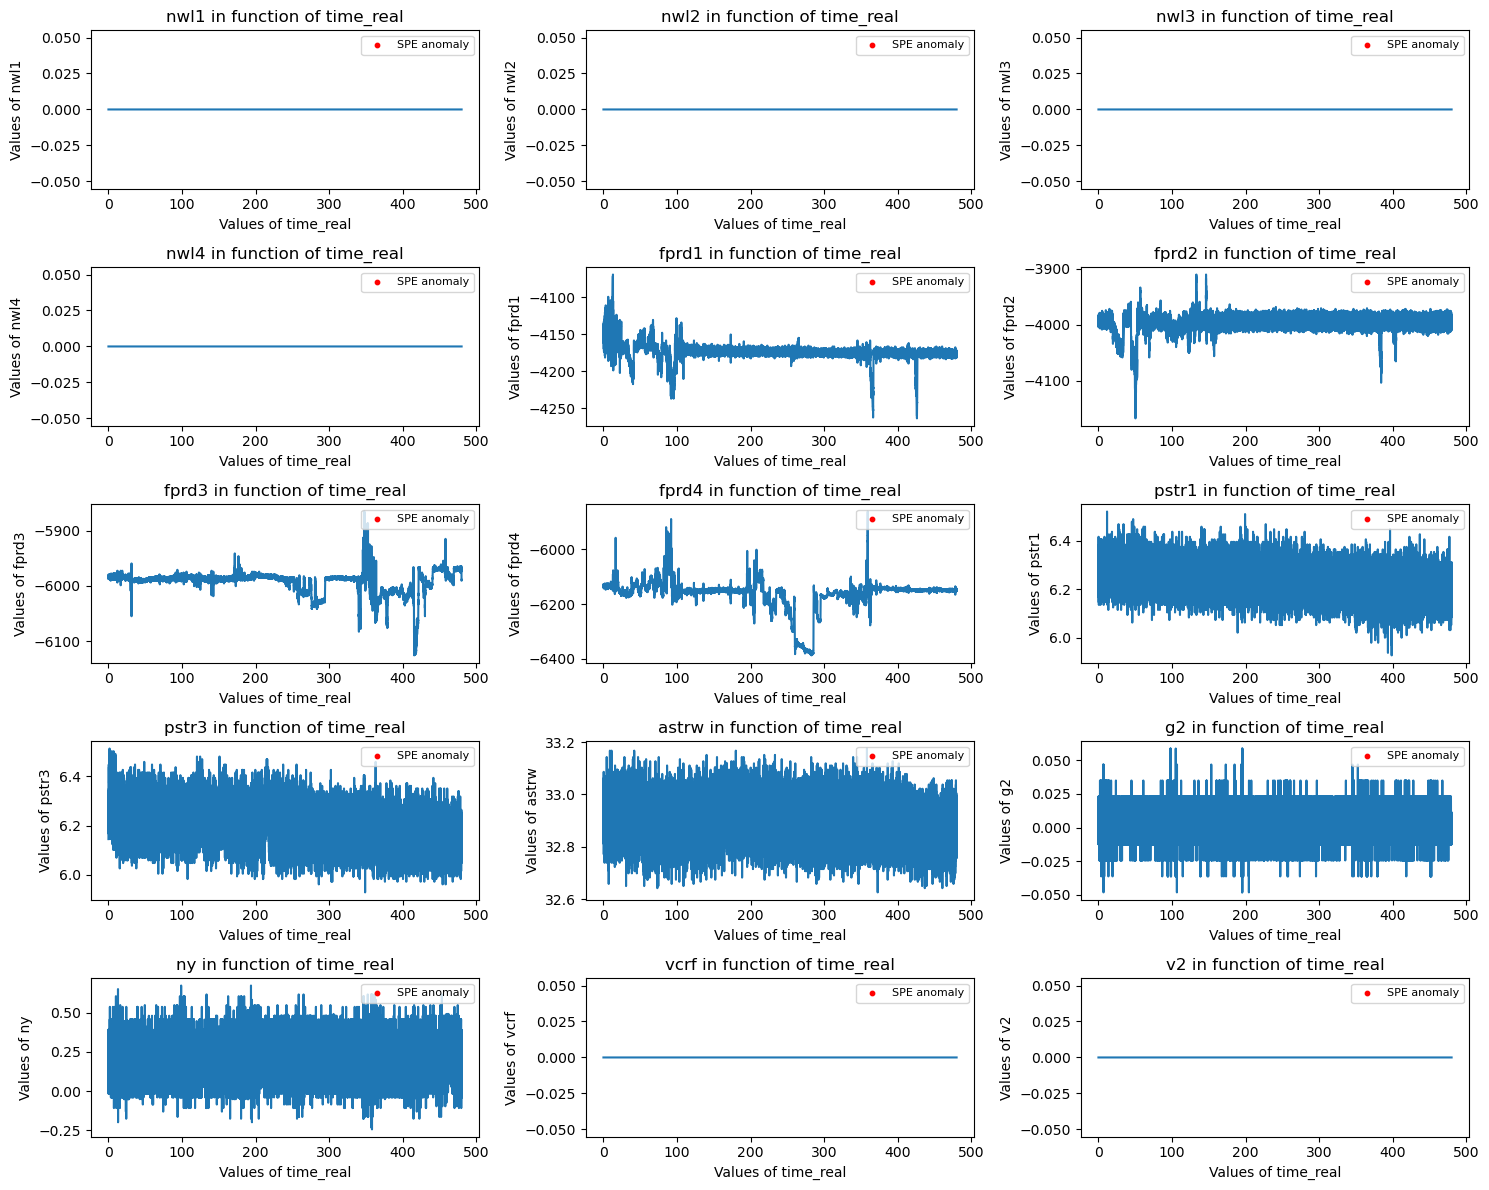

In [62]:
visualisation_anomalies(df_test, mask_dpca_anomaly, cols, method="dpca")

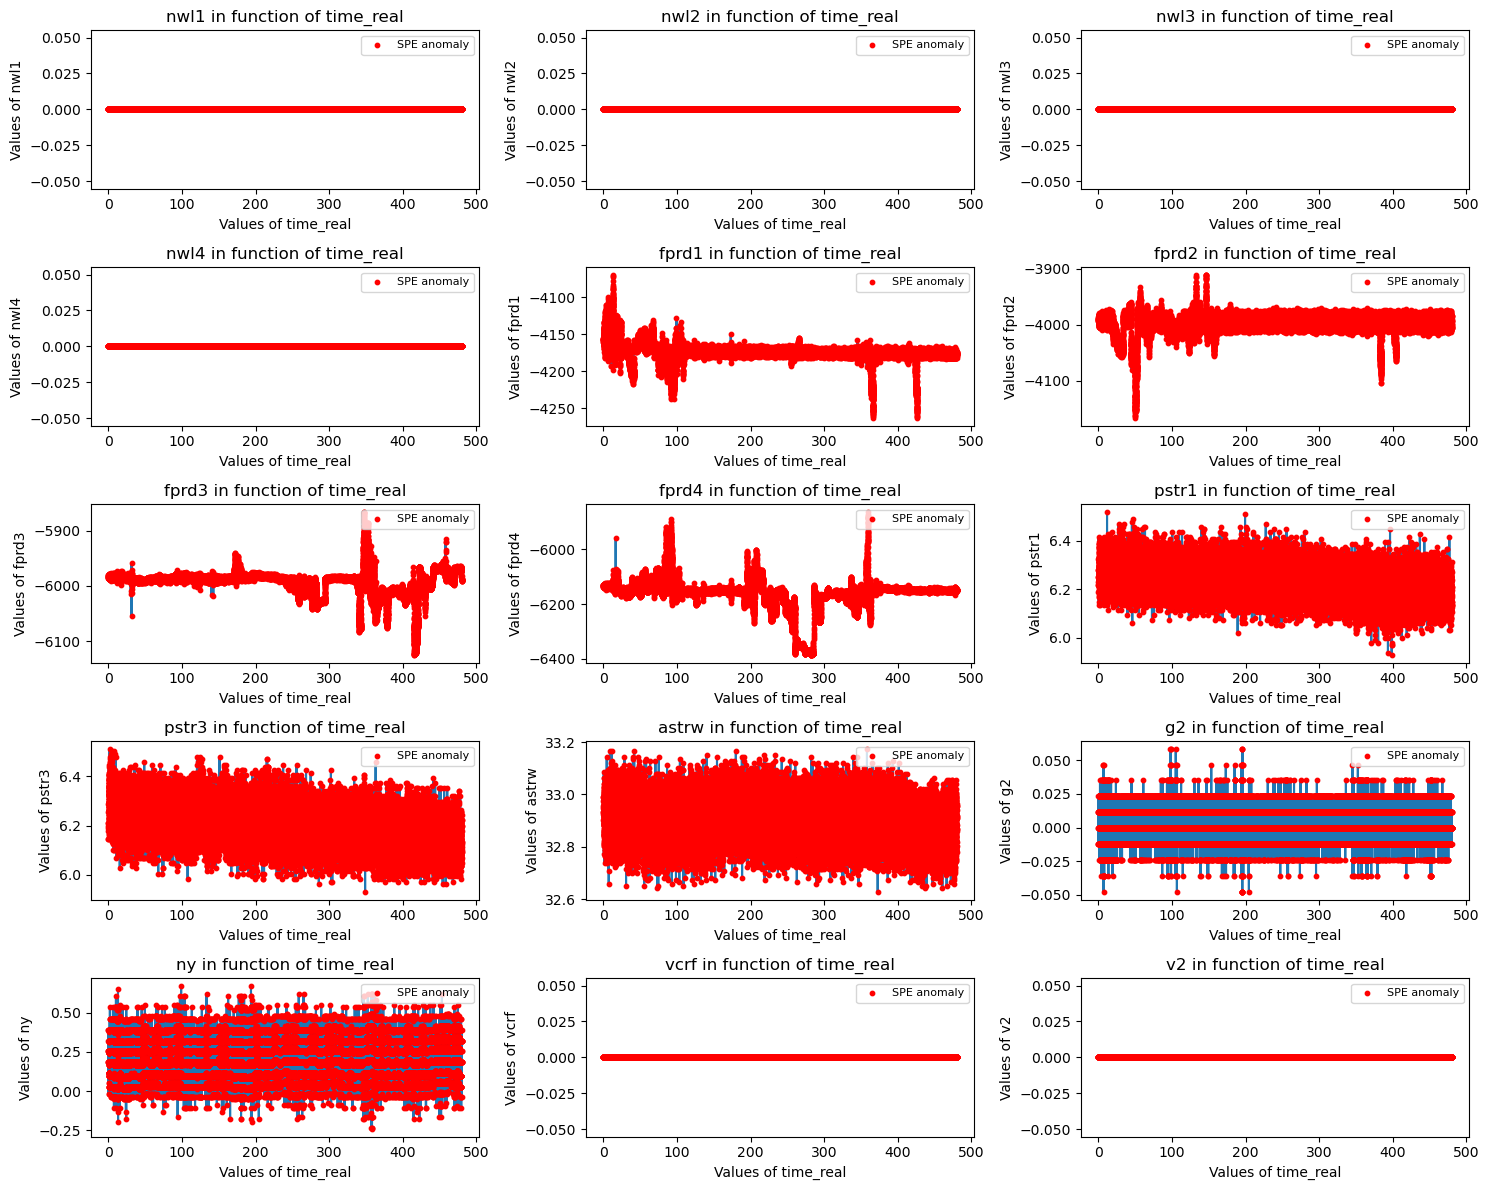

In [63]:
visualisation_anomalies(df_test, mask_dpca_if, cols, method="dpca")

## Full test

In [64]:
results = []

for session_name in session_anomaly_test:
    
    df_test = data_dict[session_name].copy()
    df_test = preprocessing.clean_dataframe(df_test)
    
    X = df_test[cols]
    n = len(X)
    
    # --- PCA ---
    mask_pca_spe = pca_anomaly_detection(X, pca, scaler, seuil, method="SPE")
    mask_pca_if  = pca_anomaly_detection(X, pca, scaler, seuil, method="IF", clf_IF=clf_if)
    
    # --- DPCA ---
    mask_dpca_spe = dpca_anomaly_detection(X, dpca, scaler, seuilD, method="SPE")
    mask_dpca_if  = dpca_anomaly_detection(X, dpca, scaler, seuilD, method="IF", clf_IF=clf_if_dy)
    
    mask_global_if = clf_glob.predict_anomalies(X)["anomaly_detected"]==1
    # --- compute percentages ---
    res = {
        "session": os.path.basename(session_name),
        "pca_spe_%": mask_pca_spe.sum() / n * 100,
        "pca_if_%":  mask_pca_if.sum() / n * 100,
        "dpca_spe_%": mask_dpca_spe.sum() / n * 100,
        "dpca_if_%":  mask_dpca_if.sum() / n * 100,
        "global_if_%": mask_global_if.sum() / n * 100,
    }
    
    results.append(res)

# convert to DataFrame
df_results = pd.DataFrame(results)

In [65]:
df_results

,session,pca_spe_%,pca_if_%,dpca_spe_%,dpca_if_%,global_if_%
0,T24S12-04_E-AL2706.csv,0.000000,100.000000,0.000000,99.983333,100.000000
1,T24S12-04_E-AL2725.csv,2.656434,90.495868,2.538371,90.023613,88.606848
2,T24S12-04_E-AL2761.csv,0.000000,100.000000,0.000000,99.953986,100.000000
3,T24S12-04_E-AL2780.csv,13.079332,1.002088,15.469729,0.981211,1.858038
4,T24S12-04_E-AL2819.csv,0.000000,100.000000,0.000000,99.983333,100.000000
5,T24S12-04_E-AL2948.csv,0.000000,95.294118,0.000000,95.294118,0.000000
6,T24S12-04_E-AL3089.csv,1.847917,71.075000,2.214583,73.852083,48.050000
7,T24S12-04_E-AL3155.csv,0.000000,100.000000,0.000000,99.983333,100.000000
8,T24S12-04_E-AL3597.csv,0.000000,100.000000,0.000000,99.983333,100.000000
9,T24S12-04_E-AL3674.csv,0.322700,79.137009,0.346672,79.277153,67.836991


## Analyze one session

We will concentrate on session 2780 where iForest detects few anomalies, while the SPE detects alot.

In [66]:
session_anomaly_test[3]

'd:\\GMM 4\\Reading seminar\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL2780.csv'

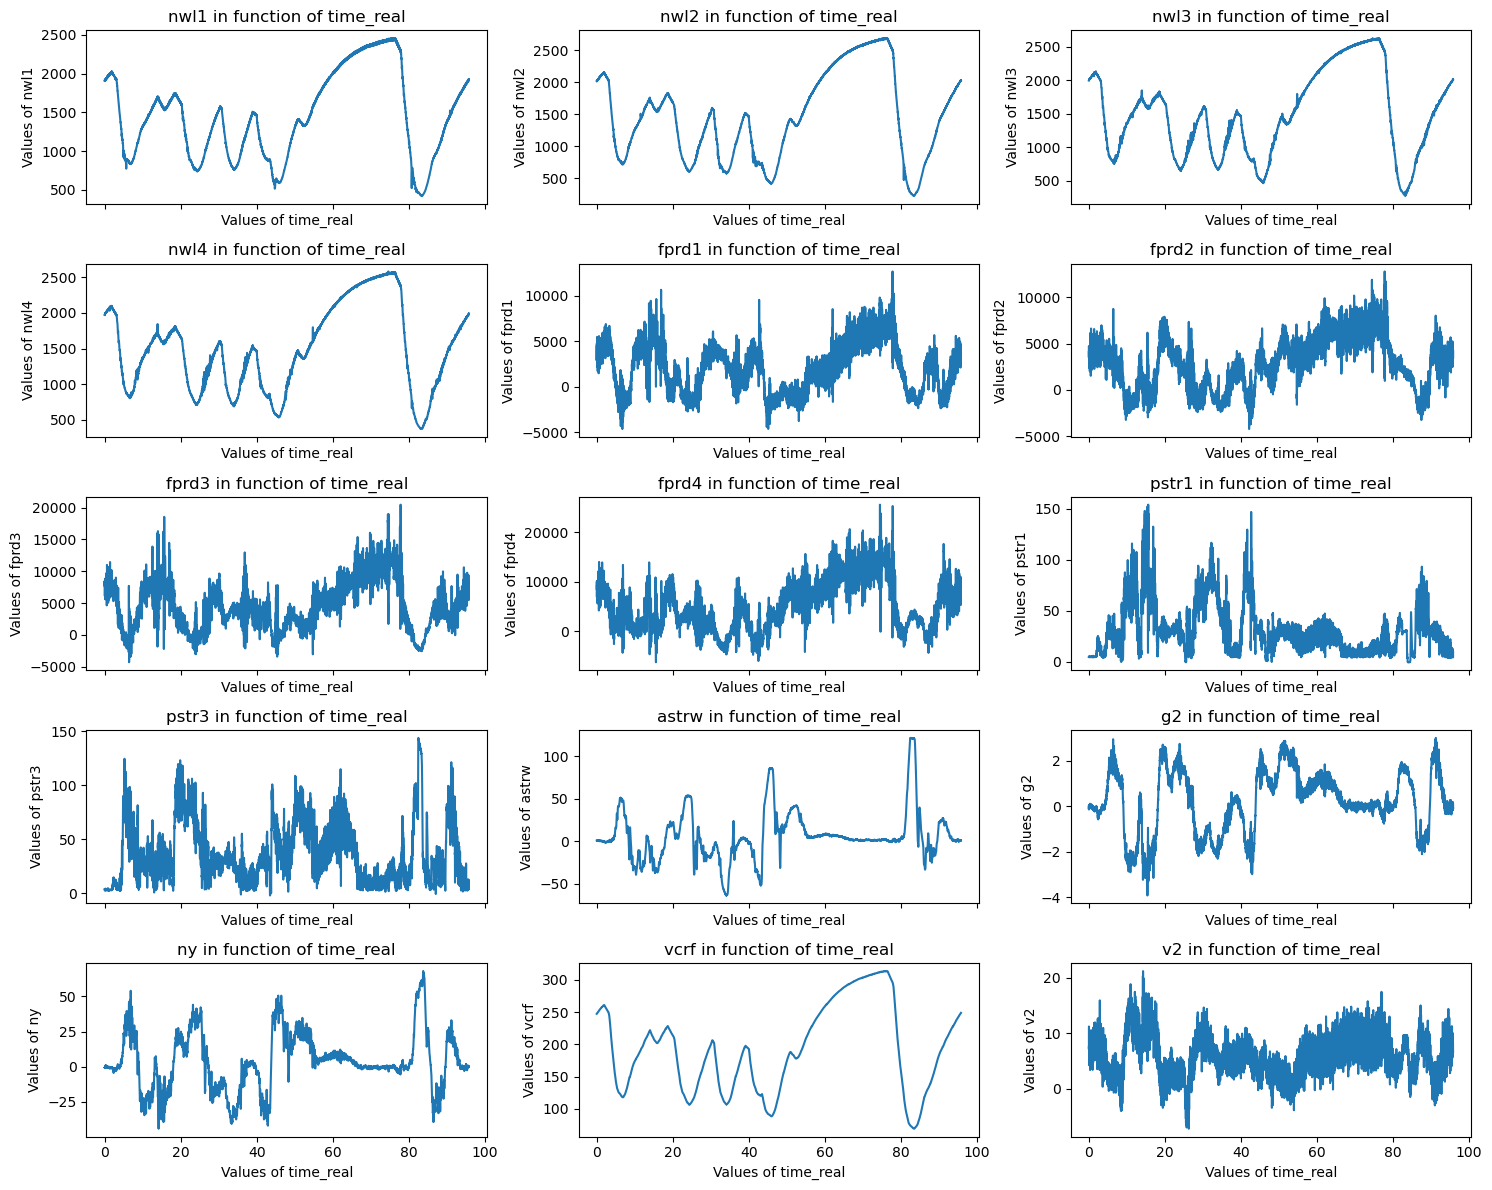

In [67]:
df_test = data_dict[session_anomaly_test[3]].copy()
df_test = preprocessing.clean_dataframe(df_test)
visualisation_plot(df_test, cols)

In [68]:
mask_pca_anomaly = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, method="SPE")
mask_pca_if = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, method="IF", clf_IF=clf_if)
mask_dpca_anomaly = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, method="SPE")
mask_dpca_if = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, method="IF", clf_IF=clf_if_dy)

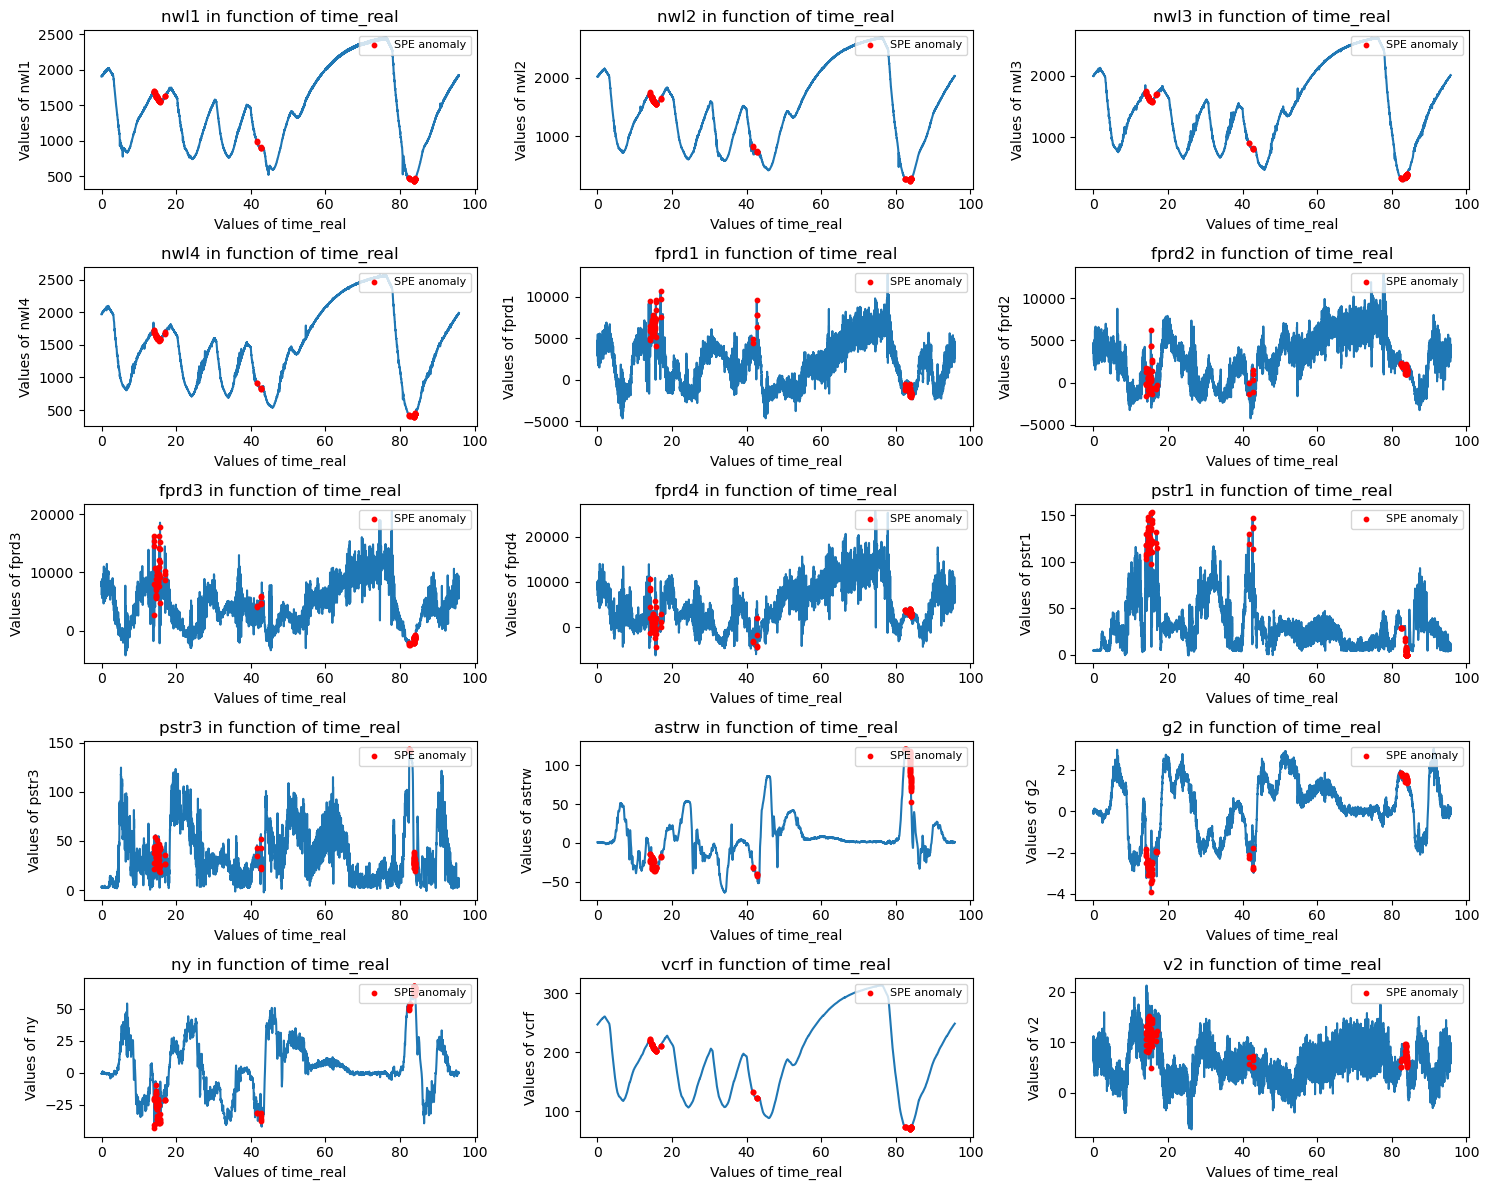

In [69]:
visualisation_anomalies(df_test, mask_pca_if, cols)

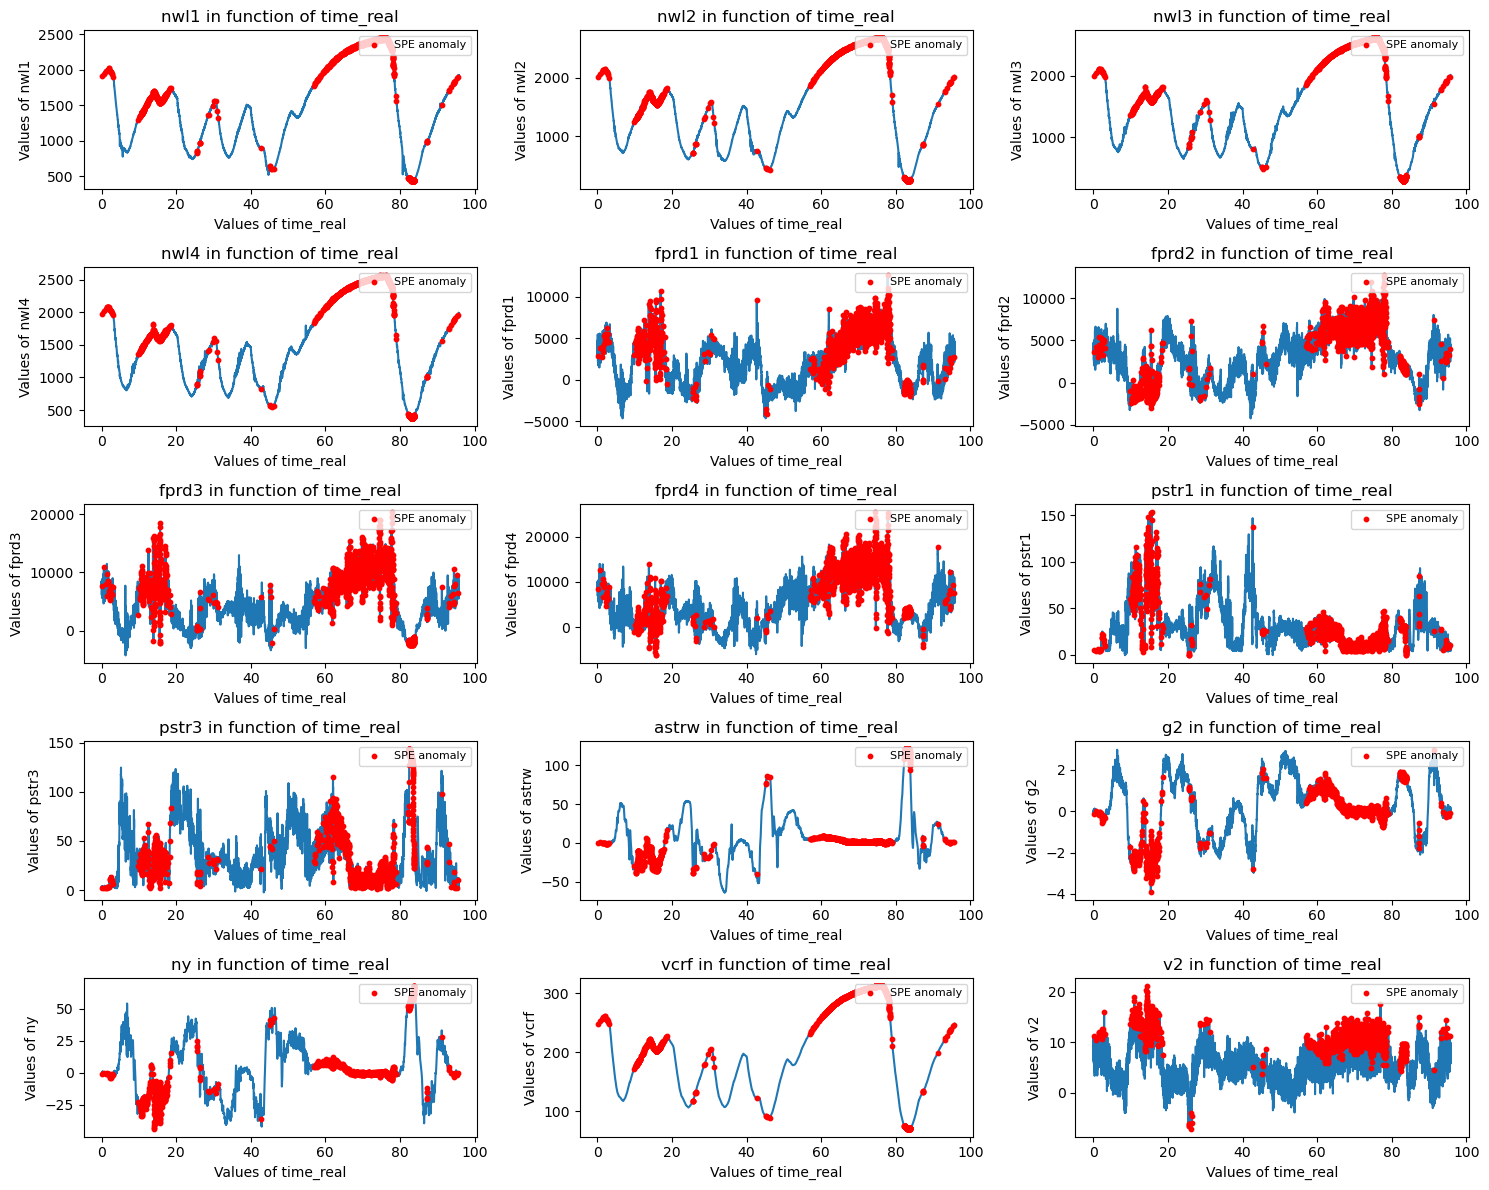

In [70]:
visualisation_anomalies(df_test, mask_pca_anomaly, cols)

## Conclusion
- SPE can't detect anomalies in many anomalous sessions
- For session 2780, the sensor v2 is not centered in 0, but non of the methods can detect.
- In general the iForest in latent space is more stable and better than iForest alone or SPE. 
